In [1]:
import os

import torch

from mapanything.models import MapAnything, init_model_from_config
from mapanything.utils.device import get_amp_dtype, get_autocast_device_type, get_device

if torch.cuda.is_available():
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

MODEL_NAME = "da3_nested"

MODEL_CONFIG = {
    "mapanything": {"resolution": 518, "norm_type": "dinov2", "patch_size": 14},
    "mapanything_apache": {"resolution": 518, "norm_type": "dinov2", "patch_size": 14},
    "mapanything_v1": {"resolution": 518, "norm_type": "dinov2", "patch_size": 14},
    "mapanything_apache_v1": {"resolution": 518, "norm_type": "dinov2", "patch_size": 14},
    "vggt": {"resolution": 518, "norm_type": "identity", "patch_size": 14},
    "pi3": {"resolution": 518, "norm_type": "identity", "patch_size": 14},
    "pi3x": {"resolution": 518, "norm_type": "identity", "patch_size": 14},
    "dust3r": {"resolution": 512, "norm_type": "dust3r", "patch_size": 16},
    "mast3r": {"resolution": 512, "norm_type": "dust3r", "patch_size": 16},
    "must3r": {"resolution": 512, "norm_type": "dust3r", "patch_size": 16},
    "pow3r": {"resolution": 512, "norm_type": "dust3r", "patch_size": 16},
    "pow3r_ba": {"resolution": 512, "norm_type": "dust3r", "patch_size": 16},
    "da3": {"resolution": 504, "norm_type": "dinov2", "patch_size": 14},
    "da3_nested": {"resolution": 504, "norm_type": "dinov2", "patch_size": 14},
    "moge_1": {"resolution": 518, "norm_type": "identity", "patch_size": 14},
    "moge_2": {"resolution": 518, "norm_type": "identity", "patch_size": 14},
}

HF_MODEL_IDS = {
    "mapanything": "facebook/map-anything",
    "mapanything_apache": "facebook/map-anything-apache",
    "mapanything_v1": "facebook/map-anything-v1",
    "mapanything_apache_v1": "facebook/map-anything-apache-v1",
}

# Pick a model to run. For the default MapAnything path, use the pretrained HF weights.
# For external models, use the config names from configs/model (for example: vggt, pi3x, da3_nested).
# MUSt3R additionally requires configs/machine/default.yaml to point at local checkpoints.
machine = "default"
device = get_device()

if MODEL_NAME not in MODEL_CONFIG:
    raise ValueError(f"Unsupported MODEL_NAME: {MODEL_NAME}. Choose from {sorted(MODEL_CONFIG)}")

model_cfg = MODEL_CONFIG[MODEL_NAME]

if MODEL_NAME in HF_MODEL_IDS:
    print(f"Loading pretrained model from {HF_MODEL_IDS[MODEL_NAME]} on {device}...")
    model = MapAnything.from_pretrained(HF_MODEL_IDS[MODEL_NAME]).to(device)
else:
    print(f"Loading {MODEL_NAME} from Hydra config on {device}...")
    model = init_model_from_config(MODEL_NAME, device=device, machine=machine)

model.eval()
print(model_cfg)


Loading da3_nested from Hydra config on cuda...


/home/kobayashi/map-anything/.venv/lib/python3.12/site-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/home/kobayashi/map-anything/.venv/lib/python3.12/site-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/home/kobayashi/map-anything/.venv/lib/python3.12/site-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/home/kobayashi/map-anything/.venv/lib/python3.12/site-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)


[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70
Initializing <class 'mapanything.models.external.da3.DA3Wrapper'> with kwargs: {'torch_hub_force_reload': False, 'pretrained_checkpoint_path': None, 'load_specific_pretrained_submodules': False, 'specific_pretrained_submodules': [], 'name': 'da3_nested', 'hf_model_name': 'depth-anything/DA3NESTED-GIANT-LARGE-1.1', 'geometric_input_config': {'ray_dirs_encoder_config': {'name': 'ray_dirs_encoder', 'in_chans': 3, 'encoder_str': 'dense_rep_encoder', 'apply_pe': False}, 'depth_encoder_config': {'name': 'depth_encoder', 'in_chans': 1, 'encoder_str': 'dense_rep_encoder', 'apply_pe': False}, 'cam_rot_encoder_config': {'name': 'cam_rot_quats_encoder', 'in_chans': 4, 'encoder_str': 'global_rep_encoder'}, 'cam_trans_encoder_config': {'name': 'cam_trans_encoder', 'in_chans': 3, 'encoder_str': 'global_rep_encoder'}, 'scale

config.json: 0.00B [00:00, ?B/s]

[INFO ] using SwiGLU layer as FFN
[INFO ] using MLP layer as FFN


model.safetensors:   0%|          | 0.00/6.76G [00:00<?, ?B/s]

{'resolution': 504, 'norm_type': 'dinov2', 'patch_size': 14}


In [2]:
from pathlib import Path

imgs_path = Path("/home/kobayashi/dataset/kitti/raw_formatted_dataset/2011_09_28_drive_0034_sync_02")
supported_suffixes = {".jpg", ".jpeg", ".png", ".heic", ".heif"}

if not imgs_path.exists():
    raise FileNotFoundError(f"Image folder does not exist: {imgs_path}")

image_files = sorted(
    path for path in imgs_path.iterdir() if path.suffix.lower() in supported_suffixes
)
if not image_files:
    raise FileNotFoundError(f"No supported images found in: {imgs_path}")

# Set max_views to a small integer like 8 for faster debugging.
max_views = None
selected_files = image_files if max_views is None else image_files[:max_views]

print(f"Found {len(image_files)} images in {imgs_path}")
print(f"Running inference on {len(selected_files)} image(s)")

Found 49 images in /home/kobayashi/dataset/kitti/raw_formatted_dataset/2011_09_28_drive_0034_sync_02
Running inference on 49 image(s)


In [3]:
from mapanything.utils.image import load_images

views = load_images(
    folder_or_list=[str(path) for path in selected_files],
    resolution_set=model_cfg["resolution"],
    norm_type=model_cfg["norm_type"],
    patch_size=model_cfg["patch_size"],
    verbose=True,
)

print(f"Loaded {len(views)} preprocessed views")
print(f"First view tensor shape: {tuple(views[0]['img'].shape)}")


Loading a list of 49 images
Calculated average aspect ratio: 3.308 from 49 images
Using target resolution 504x154 (W x H) for all images
 - Adding /home/kobayashi/dataset/kitti/raw_formatted_dataset/2011_09_28_drive_0034_sync_02/0000000000.png with resolution 1224x370 --> 504x154
 - Adding /home/kobayashi/dataset/kitti/raw_formatted_dataset/2011_09_28_drive_0034_sync_02/0000000001.png with resolution 1224x370 --> 504x154
 - Adding /home/kobayashi/dataset/kitti/raw_formatted_dataset/2011_09_28_drive_0034_sync_02/0000000002.png with resolution 1224x370 --> 504x154
 - Adding /home/kobayashi/dataset/kitti/raw_formatted_dataset/2011_09_28_drive_0034_sync_02/0000000003.png with resolution 1224x370 --> 504x154
 - Adding /home/kobayashi/dataset/kitti/raw_formatted_dataset/2011_09_28_drive_0034_sync_02/0000000004.png with resolution 1224x370 --> 504x154
 - Adding /home/kobayashi/dataset/kitti/raw_formatted_dataset/2011_09_28_drive_0034_sync_02/0000000005.png with resolution 1224x370 --> 504x154

In [4]:
import pandas as pd
import numpy as np

def parse_kitti_intrinsics(scene) -> np.ndarray:
    drive_with_num = Path(scene).stem
    date = "_".join(drive_with_num.split("_")[:3])
    image_num = drive_with_num.split("_")[-1]
    calib_path = Path(
        f"/home/kobayashi/dataset/kitti/raw_data/{date}/calib_cam_to_cam.txt"
    )
    calib_df = pd.read_csv(
        calib_path,
        sep=r":\s+",
        header=None,
        names=["key", "raw"],
        engine="python",
        comment="#",
    )
    k_idx = calib_df[calib_df["key"].str.contains(f"K_{image_num}")].index[0]
    k_values = calib_df.loc[k_idx, "raw"].split(" ")
    k_values = [float(v) for v in k_values]
    d_idx = calib_df[calib_df["key"].str.contains(f"D_{image_num}")].index[0]
    d_values = calib_df.loc[d_idx, "raw"].split(" ")
    d_values = [float(v) for v in d_values]
    rect_idx = calib_df[calib_df["key"].str.contains(f"P_rect_{image_num}")].index[0]
    rect_values = calib_df.loc[rect_idx, "raw"].split(" ")
    rect_values = [float(v) for v in rect_values]
    rect_matrix = np.array(rect_values).astype(np.float32).reshape(3, 4)
    rect_intrinsics = rect_matrix[:, :3]

    return (
        np.array(k_values).astype(np.float32).reshape(3, 3),
        np.array(d_values).astype(np.float32),
        rect_intrinsics,
    )

In [5]:
drive_name = Path(selected_files[0]).parent.stem
_, _, rect_intrinsics = parse_kitti_intrinsics(drive_name)

In [6]:
for i, view in enumerate(views):
    view["img"] = view["img"].to(device)
    view["intrinsics"] = torch.from_numpy(rect_intrinsics).unsqueeze(0).to(device)

In [7]:
views[0]["img"].shape, views[0]["intrinsics"].shape

(torch.Size([1, 3, 154, 504]), torch.Size([1, 3, 3]))

[INFO ] Selecting reference view using strategy: saddle_balanced
Generated predictions for 49 views
['cam_quats', 'cam_trans', 'conf', 'depth_along_ray', 'pts3d', 'pts3d_cam', 'ray_directions']


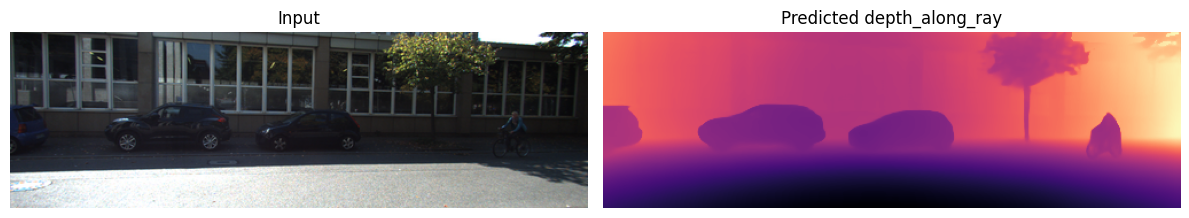

In [8]:
import matplotlib.pyplot as plt

from mapanything.utils.image import rgb

amp_enabled = device.type != "cpu"
amp_dtype = get_amp_dtype(device, "bf16")
autocast_device_type = get_autocast_device_type(device)

with torch.no_grad():
    if MODEL_NAME in HF_MODEL_IDS:
        predictions = model.infer(
            views,
            memory_efficient_inference=True,
            minibatch_size=1 if device.type == "cuda" else None,
            use_amp=amp_enabled,
            amp_dtype="bf16",
            apply_mask=True,
            mask_edges=False,
        )
    else:
        with torch.autocast(
            autocast_device_type,
            enabled=amp_enabled,
            dtype=amp_dtype,
        ):
            predictions = model(views)

print(f"Generated predictions for {len(predictions)} views")
print(sorted(predictions[0].keys()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(rgb(views[0]["img"], norm_type=model_cfg["norm_type"])[0])
axes[0].set_title("Input")
axes[0].axis("off")

if "depth_along_ray" in predictions[0]:
    depth = predictions[0]["depth_along_ray"][0, ..., 0].detach().cpu()
    axes[1].imshow(depth, cmap="magma")
    axes[1].set_title("Predicted depth_along_ray")
    axes[1].axis("off")
else:
    axes[1].text(0.5, 0.5, "No depth_along_ray output", ha="center", va="center")
    axes[1].axis("off")

plt.tight_layout()
plt.show()


In [9]:
predictions[0].keys()

dict_keys(['pts3d', 'pts3d_cam', 'ray_directions', 'depth_along_ray', 'cam_trans', 'cam_quats', 'conf'])